In [1]:
# ============================================================
# NOTEBOOK 01: DATA COLLECTION
# Azerbaijan Non-Oil Fiscal Balance Nowcasting
# Author: Mammad Mammadov
# ============================================================

import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All libraries loaded successfully")
print(f"pandas version: {pd.__version__}")

All libraries loaded successfully
pandas version: 3.0.2


In [3]:
# ============================================================
# CELL 2: FETCH ALL INDICATORS INCLUDING OIL PRICE
# ============================================================

import wbgapi as wb
import pandas as pd
from functools import reduce

COUNTRY = "AZE"
START_YEAR = 2009
END_YEAR = 2023

INDICATORS = {
    "NY.GDP.MKTP.KD.ZG": "GDP_Growth_Pct",
    "FP.CPI.TOTL.ZG":    "CPI_Inflation_Pct",
    "GC.REV.XGRT.GD.ZS": "Gov_Revenue_GDP_Pct",
    "BN.CAB.XOKA.GD.ZS": "Current_Account_GDP_Pct",
    "SL.UEM.TOTL.ZS":    "Unemployment_Pct",
    "PA.NUS.FCRF":        "Exchange_Rate_AZN_USD",
}

def fetch_indicator(code, name):
    try:
        raw = wb.data.DataFrame(
            code,
            economy=COUNTRY,
            time=range(START_YEAR, END_YEAR + 1)
        )
        # Handle both possible shapes wbgapi returns
        if isinstance(raw.index, pd.MultiIndex):
            raw = raw.reset_index()
            # Find the time column
            time_col = [c for c in raw.columns if "time" in str(c).lower() or "Time" in str(c)]
            if time_col:
                raw = raw[["economy", time_col[0], "value"]].copy()
                raw.columns = ["economy", "Year", name]
                raw = raw[raw["economy"] == COUNTRY][["Year", name]]
        else:
            raw = raw.T.reset_index()
            raw.columns = ["Year", name]

        raw["Year"] = raw["Year"].astype(str).str.replace("YR", "").str.strip()
        raw = raw[raw["Year"].str.isnumeric()]
        raw["Year"] = raw["Year"].astype(int)
        raw = raw[(raw["Year"] >= START_YEAR) & (raw["Year"] <= END_YEAR)]
        raw = raw.reset_index(drop=True)
        print(f"  OK: {name} — {len(raw)} rows")
        return raw
    except Exception as e:
        print(f"  ERROR {name}: {e}")
        return None

print("Fetching data from World Bank API...")
dfs = []
for code, name in INDICATORS.items():
    result = fetch_indicator(code, name)
    if result is not None and len(result) > 0:
        dfs.append(result)

print(f"\nSuccessfully fetched {len(dfs)} indicators")

if len(dfs) == 0:
    print("ERROR: No data fetched. Check internet connection.")
else:
    df_merged = reduce(lambda l, r: pd.merge(l, r, on="Year", how="outer"), dfs)
    df_merged = df_merged.sort_values("Year").reset_index(drop=True)
    print(f"Merged dataset shape: {df_merged.shape}")
    print(df_merged)

Fetching data from World Bank API...
  OK: GDP_Growth_Pct — 15 rows
  OK: CPI_Inflation_Pct — 15 rows
  OK: Gov_Revenue_GDP_Pct — 15 rows
  OK: Current_Account_GDP_Pct — 15 rows
  OK: Unemployment_Pct — 15 rows
  OK: Exchange_Rate_AZN_USD — 15 rows

Successfully fetched 6 indicators
Merged dataset shape: (15, 7)
    Year  GDP_Growth_Pct  CPI_Inflation_Pct  Gov_Revenue_GDP_Pct  \
0   2009        9.369503           1.457048            40.889850   
1   2010        4.788832           5.726872            46.828918   
2   2011       -1.572997           7.858333            45.481356   
3   2012        2.202939           1.066213            41.273973   
4   2013        5.843416           2.415717            40.405796   
5   2014        2.797585           1.373442            39.896398   
6   2015        1.049546           4.027686            34.183707   
7   2016       -3.063598          12.443375            34.919868   
8   2017        0.153615          12.935918            35.075877   
9   20

In [4]:
# ============================================================
# CELL 3: CLEAN DATA + HANDLE OIL PRICE GAP
# ============================================================

# If Oil_Price_Brent_USD is all NaN, use manual Brent prices
# These are publicly available annual averages
oil_prices_manual = {
    2009: 61.5, 2010: 79.5, 2011: 111.3, 2012: 111.7,
    2013: 108.7, 2014: 98.9, 2015: 52.4, 2016: 43.7,
    2017: 54.2, 2018: 71.1, 2019: 64.0, 2020: 41.8,
    2021: 70.9, 2022: 100.9, 2023: 82.5
}

# Check if oil column exists and has data
if "Oil_Price_Brent_USD" not in df_merged.columns or df_merged["Oil_Price_Brent_USD"].isna().all():
    print("Oil price not from API — using manual Brent annual averages (EIA/World Bank source)")
    df_merged["Oil_Price_Brent_USD"] = df_merged["Year"].map(oil_prices_manual)
else:
    missing_oil = df_merged["Oil_Price_Brent_USD"].isna().sum()
    if missing_oil > 0:
        df_merged["Oil_Price_Brent_USD"] = df_merged["Oil_Price_Brent_USD"].fillna(
            df_merged["Year"].map(oil_prices_manual)
        )
    print("Oil price from API with gaps filled")

# Interpolate small gaps in other columns
numeric_cols = [c for c in df_merged.columns if c != "Year"]
df_merged[numeric_cols] = df_merged[numeric_cols].interpolate(method="linear", limit=2)

# Add period labels
def label_period(year):
    if year <= 2014: return "Pre-crisis"
    elif year <= 2016: return "Oil-crash"
    elif year <= 2019: return "Recovery"
    elif year == 2020: return "COVID"
    else: return "Post-COVID"

df_merged["Period"] = df_merged["Year"].apply(label_period)

print("\nMissing values after cleaning:")
print(df_merged.isnull().sum())
print("\nFinal dataset:")
print(df_merged.to_string())

Oil price not from API — using manual Brent annual averages (EIA/World Bank source)

Missing values after cleaning:
Year                       0
GDP_Growth_Pct             0
CPI_Inflation_Pct          0
Gov_Revenue_GDP_Pct        0
Current_Account_GDP_Pct    0
Unemployment_Pct           0
Exchange_Rate_AZN_USD      0
Oil_Price_Brent_USD        0
Period                     0
dtype: int64

Final dataset:
    Year  GDP_Growth_Pct  CPI_Inflation_Pct  Gov_Revenue_GDP_Pct  Current_Account_GDP_Pct  Unemployment_Pct  Exchange_Rate_AZN_USD  Oil_Price_Brent_USD      Period
0   2009        9.369503           1.457048            40.889850                22.972044              5.74               0.803783                 61.5  Pre-crisis
1   2010        4.788832           5.726872            46.828918                28.426831              5.63               0.802650                 79.5  Pre-crisis
2   2011       -1.572997           7.858333            45.481356                25.995767             

In [5]:
# ============================================================
# CELL 4: SAVE DATA
# ============================================================

import os

os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/clean", exist_ok=True)

# Save raw
df_merged.to_csv("../data/raw/world_bank_raw_data.csv", index=False)

# Save clean
df_clean = df_merged.copy()
df_clean.to_csv("../data/clean/aze_fiscal_cleaned.csv", index=False)

print("Files saved:")
print(f"  ../data/raw/world_bank_raw_data.csv — {df_merged.shape}")
print(f"  ../data/clean/aze_fiscal_cleaned.csv — {df_clean.shape}")
print("\nColumns in dataset:")
for col in df_clean.columns:
    print(f"  {col}")

Files saved:
  ../data/raw/world_bank_raw_data.csv — (15, 9)
  ../data/clean/aze_fiscal_cleaned.csv — (15, 9)

Columns in dataset:
  Year
  GDP_Growth_Pct
  CPI_Inflation_Pct
  Gov_Revenue_GDP_Pct
  Current_Account_GDP_Pct
  Unemployment_Pct
  Exchange_Rate_AZN_USD
  Oil_Price_Brent_USD
  Period


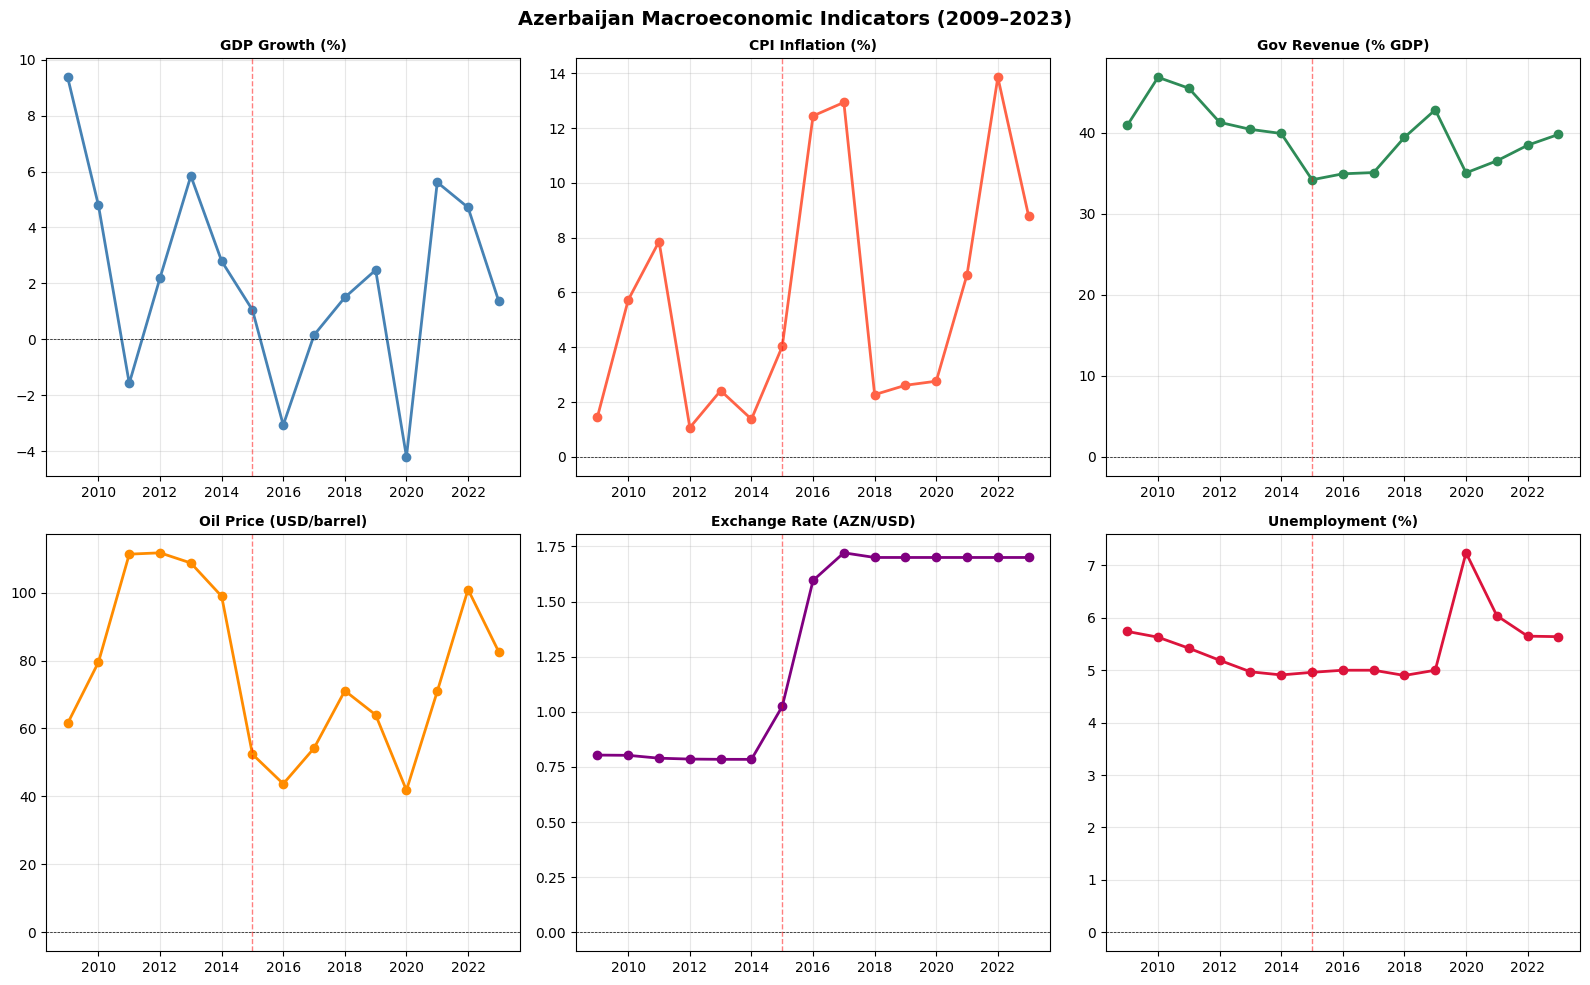

Chart saved to outputs/eda_overview.png


In [6]:
# ============================================================
# CELL 5: EXPLORATORY DATA ANALYSIS
# ============================================================

os.makedirs("../outputs", exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Azerbaijan Macroeconomic Indicators (2009–2023)",
             fontsize=14, fontweight="bold")

plots = [
    ("GDP_Growth_Pct",          "GDP Growth (%)",           "steelblue"),
    ("CPI_Inflation_Pct",       "CPI Inflation (%)",        "tomato"),
    ("Gov_Revenue_GDP_Pct",     "Gov Revenue (% GDP)",      "seagreen"),
    ("Oil_Price_Brent_USD",     "Oil Price (USD/barrel)",   "darkorange"),
    ("Exchange_Rate_AZN_USD",   "Exchange Rate (AZN/USD)",  "purple"),
    ("Unemployment_Pct",        "Unemployment (%)",         "crimson"),
]

for i, (col, title, color) in enumerate(plots):
    ax = axes[i // 3][i % 3]
    if col in df_clean.columns:
        ax.plot(df_clean["Year"], df_clean[col],
                marker="o", color=color, linewidth=2)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.grid(True, alpha=0.3)
        # Mark 2015 oil crash
        ax.axvline(2015, color="red", linewidth=1,
                   linestyle="--", alpha=0.5, label="2015 crash")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/eda_overview.png")

In [8]:
# ============================================================
# CELL 6: STATIONARITY TESTING (ADF TEST)
# ============================================================

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    # Drop NaN values
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    pval = result[1]
    stationary = "STATIONARY" if pval < 0.05 else "NON-STATIONARY"
    print(f"{name:35} | p-value: {pval:.4f} | {stationary}")
    return pval

print("=" * 70)
print("AUGMENTED DICKEY-FULLER TEST — NULL: Series has a unit root")
print("If p < 0.05 → reject null → series is STATIONARY")
print("=" * 70)

target_cols = [
    "GDP_Growth_Pct", "CPI_Inflation_Pct", "Gov_Revenue_GDP_Pct",
    "Oil_Price_Brent_USD", "Exchange_Rate_AZN_USD"
]

results = {}
for col in target_cols:
    if col in df_clean.columns:
        results[col] = adf_test(df_clean[col], col)

print("\nNote: Non-stationary series will be first-differenced before ARIMA")

AUGMENTED DICKEY-FULLER TEST — NULL: Series has a unit root
If p < 0.05 → reject null → series is STATIONARY
GDP_Growth_Pct                      | p-value: 0.0021 | STATIONARY
CPI_Inflation_Pct                   | p-value: 0.4760 | NON-STATIONARY
Gov_Revenue_GDP_Pct                 | p-value: 0.0000 | STATIONARY
Oil_Price_Brent_USD                 | p-value: 0.0000 | STATIONARY
Exchange_Rate_AZN_USD               | p-value: 0.6318 | NON-STATIONARY

Note: Non-stationary series will be first-differenced before ARIMA
